In [1]:
import pandas as pd
import numpy as np

fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [2]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [5]:
import pandas as pd

if "fraud_df" not in globals():
    fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

fraud_df.dropna(inplace=True)

In [6]:
fraud_df["age"].fillna(fraud_df["age"].median(), inplace=True)

/tmp/ipykernel_13331/1659076398.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  fraud_df["age"].fillna(fraud_df["age"].median(), inplace=True)


0         39
1         53
2         53
3         41
4         45
          ..
151107    28
151108    32
151109    26
151110    37
151111    38
Name: age, Length: 151112, dtype: int64

In [7]:
print(fraud_df.duplicated().sum())

fraud_df.drop_duplicates(inplace=True)

0


In [6]:
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])

In [7]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [8]:
fraud_df["class"].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [9]:
fraud_df["class"].value_counts(normalize=True)*100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

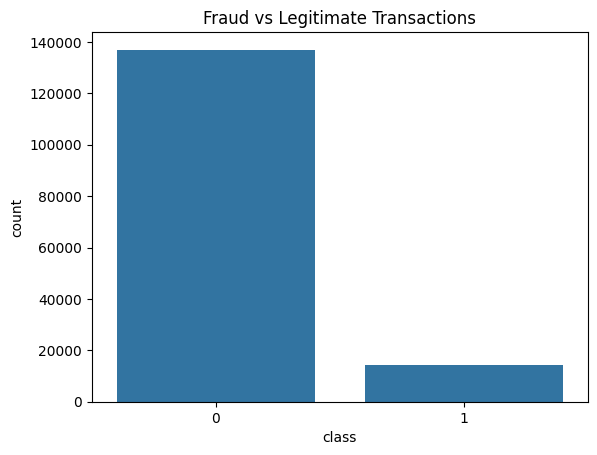

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="class", data=fraud_df)
plt.title("Fraud vs Legitimate Transactions")
plt.show()

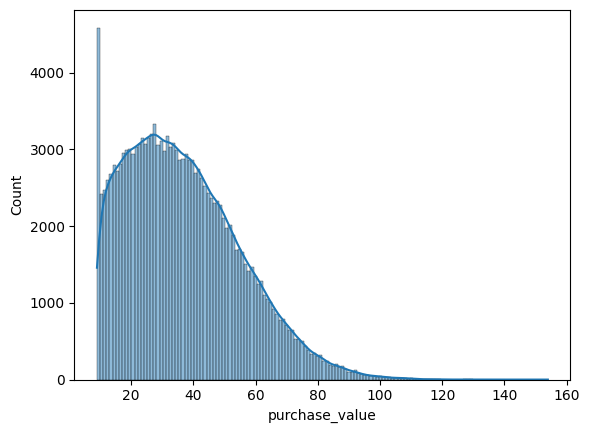

In [11]:
sns.histplot(fraud_df["purchase_value"], kde=True)
plt.show()

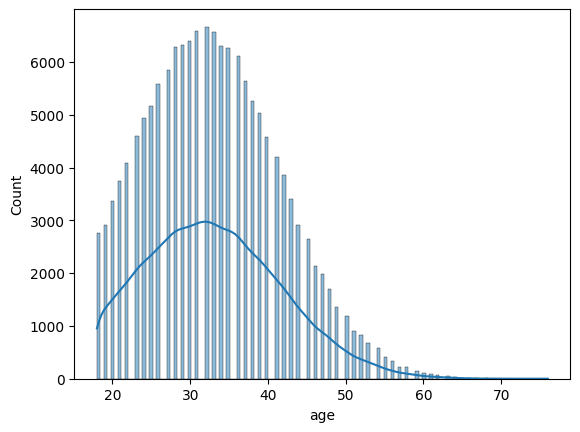

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(fraud_df["age"], kde=True)
plt.show()

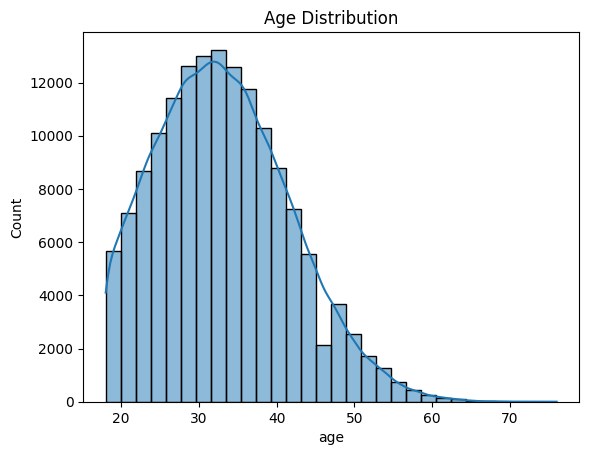

In [10]:
sns.histplot(fraud_df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

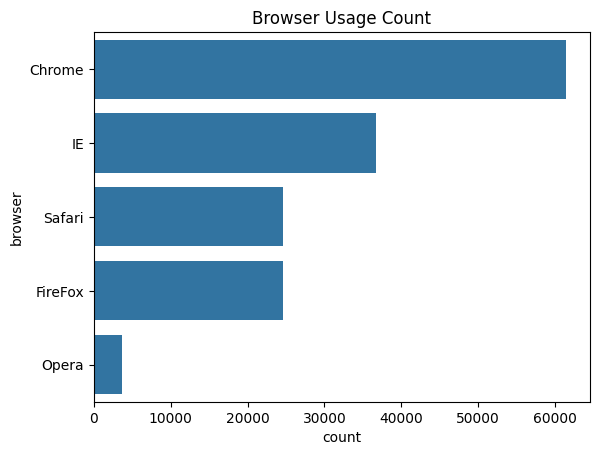

In [11]:
sns.countplot(
    y="browser",
    data=fraud_df,
    order=fraud_df["browser"].value_counts().index
)
plt.title("Browser Usage Count")
plt.show()

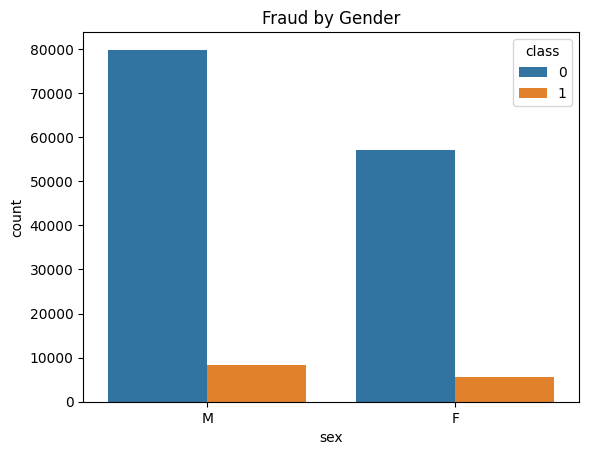

In [12]:
sns.countplot(
    x="sex",
    hue="class",
    data=fraud_df
)
plt.title("Fraud by Gender")
plt.show()

In [14]:
if "merged_df" not in globals():
    fraud_df["ip_address"] = fraud_df["ip_address"].astype(int)
    ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(int)
    ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(int)

    fraud_df = fraud_df.sort_values("ip_address")
    ip_df = ip_df.sort_values("lower_bound_ip_address")

    merged_df = pd.merge_asof(
        fraud_df,
        ip_df,
        left_on="ip_address",
        right_on="lower_bound_ip_address",
        direction="backward"
    )
    merged_df = merged_df[
        merged_df["ip_address"] <= merged_df["upper_bound_ip_address"]
    ]

country_fraud = (
    merged_df.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

country_fraud.plot(kind="bar")
plt.title("Top 10 Countries by Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()

SyntaxError: invalid syntax (285637542.py, line 2)

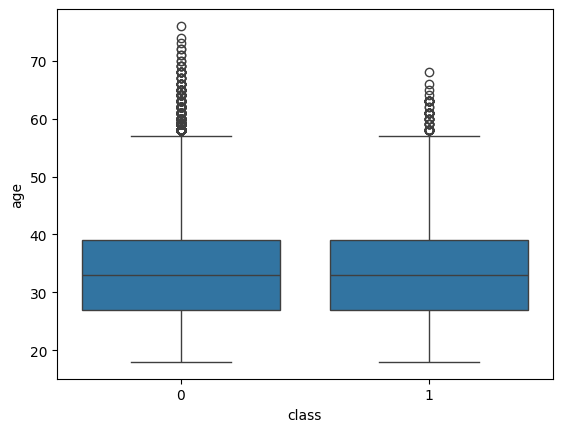

In [12]:
sns.boxplot(
    x="class",
    y="age",
    data=fraud_df
)
plt.show()

In [13]:
pd.crosstab(
    fraud_df["browser"],
    fraud_df["class"]
)

class,0,1
browser,,
Chrome,55363,6069
FireFox,22268,2342
IE,33540,3187
Opera,3348,328
Safari,22442,2225


Geolocation Integration

In [14]:
fraud_df["ip_address"] = fraud_df["ip_address"].astype(int)

In [15]:
fraud_df = fraud_df.sort_values("ip_address")

ip_df = ip_df.sort_values(
    "lower_bound_ip_address"
)

In [17]:
ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(int)
ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(int)

merged_df = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [18]:
merged_df = merged_df[
    merged_df["ip_address"] <=
    merged_df["upper_bound_ip_address"]
]

In [19]:
country_fraud = (
    merged_df.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
)

country_fraud.head(10)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

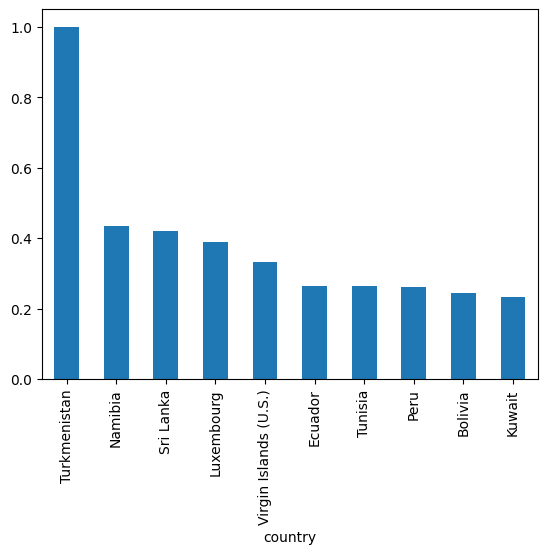

In [20]:
country_fraud.head(10).plot(
    kind="bar"
)
plt.show()

In [21]:
merged_df.to_csv(
    "../data/processed/fraud_with_country.csv",
    index=False
)